In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
img_emo_df = pd.read_csv("gpt-image-1.5_generated_images.batch.emotions.csv")

In [4]:
orig_df = pd.read_csv("diffusiondb-2m_random_10k-master-annotations.csv")

In [5]:
orig_df.columns

Index(['path', 'prompt', 'img_amusement', 'img_awe', 'img_contentment',
       'img_excitement', 'img_anger', 'img_disgust', 'img_fear', 'img_sadness',
       'text_amusement', 'text_surprise', 'text_joy', 'text_excitement',
       'text_anger', 'text_disgust', 'text_fear', 'text_sadness',
       'text_admiration', 'text_annoyance', 'text_approval', 'text_caring',
       'text_confusion', 'text_curiosity', 'text_desire',
       'text_disappointment', 'text_disapproval', 'text_embarrassment',
       'text_gratitude', 'text_grief', 'text_love', 'text_nervousness',
       'text_optimism', 'text_pride', 'text_realization', 'text_relief',
       'text_remorse'],
      dtype='object')

In [6]:
orig_df["img_id"] = orig_df["path"].apply(lambda s: int(s.rpartition("/")[-1].replace(".png","")))

In [7]:
img_emo_df["img_id_raw"] = img_emo_df["img_id"]
img_emo_df["img_id"] = img_emo_df["img_id"].apply(lambda s: int(s.replace("img.","")))

In [8]:
img_emo_df

,img_id,img_amusement,img_awe,img_contentment,img_excitement,img_anger,img_disgust,img_fear,img_sadness,img_id_raw
0,2062,0.023082,0.023449,0.025382,0.001484,0.560899,0.014845,0.212339,0.138520,img.00002062
1,2460,0.032744,0.073468,0.004304,0.007407,0.021842,0.004051,0.765134,0.091050,img.00002460
2,6317,0.140612,0.043718,0.102348,0.010898,0.075656,0.296297,0.268042,0.062430,img.00006317
3,291,0.198773,0.497123,0.074653,0.117578,0.031759,0.021544,0.033757,0.024814,img.00000291
4,4208,0.826381,0.020632,0.040620,0.015850,0.009147,0.020930,0.057562,0.008878,img.00004208
...,...,...,...,...,...,...,...,...,...,...
1637,497,0.002748,0.802986,0.000928,0.001743,0.114903,0.002448,0.073056,0.001188,img.00000497
1638,5836,0.011007,0.948571,0.024843,0.002258,0.000723,0.001297,0.005300,0.006001,img.00005836
1639,969,0.115070,0.122556,0.032628,0.016353,0.057580,0.184115,0.284304,0.187394,img.00000969
1640,8285,0.003947,0.130932,0.003063,0.000978,0.024505,0.003703,0.820687,0.012185,img.00008285


In [9]:
merged_df = img_emo_df.set_index("img_id").join(orig_df.set_index("img_id"), lsuffix="_gpt")

In [10]:
merged_df

,img_amusement_gpt,img_awe_gpt,img_contentment_gpt,img_excitement_gpt,img_anger_gpt,img_disgust_gpt,img_fear_gpt,img_sadness_gpt,img_id_raw,path,...,text_embarrassment,text_gratitude,text_grief,text_love,text_nervousness,text_optimism,text_pride,text_realization,text_relief,text_remorse
img_id,,,,,,,,,,,,,,,,,,,,,
2062,0.023082,0.023449,0.025382,0.001484,0.560899,0.014845,0.212339,0.138520,img.00002062,diffusiondb_images_2m_random_10k/2062.png,...,0.000489,0.000291,0.000255,0.000284,0.000264,0.000324,0.000291,0.002279,0.000253,0.000253
2460,0.032744,0.073468,0.004304,0.007407,0.021842,0.004051,0.765134,0.091050,img.00002460,diffusiondb_images_2m_random_10k/2460.png,...,0.000360,0.000266,0.000223,0.000283,0.000240,0.000360,0.000319,0.009556,0.000234,0.000243
6317,0.140612,0.043718,0.102348,0.010898,0.075656,0.296297,0.268042,0.062430,img.00006317,diffusiondb_images_2m_random_10k/6317.png,...,0.000384,0.000279,0.000233,0.000754,0.000242,0.000416,0.000402,0.009311,0.000240,0.000239
291,0.198773,0.497123,0.074653,0.117578,0.031759,0.021544,0.033757,0.024814,img.00000291,diffusiondb_images_2m_random_10k/291.png,...,0.000340,0.000339,0.000234,0.000245,0.000253,0.000425,0.000394,0.002418,0.000227,0.000259
4208,0.826381,0.020632,0.040620,0.015850,0.009147,0.020930,0.057562,0.008878,img.00004208,diffusiondb_images_2m_random_10k/4208.png,...,0.000627,0.000296,0.000281,0.000299,0.000283,0.000295,0.000434,0.001009,0.000252,0.000268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
497,0.002748,0.802986,0.000928,0.001743,0.114903,0.002448,0.073056,0.001188,img.00000497,diffusiondb_images_2m_random_10k/497.png,...,0.000487,0.000509,0.000262,0.001261,0.000275,0.003793,0.000739,0.012117,0.000381,0.000255
5836,0.011007,0.948571,0.024843,0.002258,0.000723,0.001297,0.005300,0.006001,img.00005836,diffusiondb_images_2m_random_10k/5836.png,...,0.000366,0.000312,0.000246,0.000378,0.000263,0.000286,0.000427,0.000764,0.000261,0.000257
969,0.115070,0.122556,0.032628,0.016353,0.057580,0.184115,0.284304,0.187394,img.00000969,diffusiondb_images_2m_random_10k/969.png,...,0.000288,0.000218,0.000212,0.000248,0.000223,0.000460,0.000335,0.001231,0.000221,0.000229


In [11]:
merged_df.columns

Index(['img_amusement_gpt', 'img_awe_gpt', 'img_contentment_gpt',
       'img_excitement_gpt', 'img_anger_gpt', 'img_disgust_gpt',
       'img_fear_gpt', 'img_sadness_gpt', 'img_id_raw', 'path', 'prompt',
       'img_amusement', 'img_awe', 'img_contentment', 'img_excitement',
       'img_anger', 'img_disgust', 'img_fear', 'img_sadness', 'text_amusement',
       'text_surprise', 'text_joy', 'text_excitement', 'text_anger',
       'text_disgust', 'text_fear', 'text_sadness', 'text_admiration',
       'text_annoyance', 'text_approval', 'text_caring', 'text_confusion',
       'text_curiosity', 'text_desire', 'text_disappointment',
       'text_disapproval', 'text_embarrassment', 'text_gratitude',
       'text_grief', 'text_love', 'text_nervousness', 'text_optimism',
       'text_pride', 'text_realization', 'text_relief', 'text_remorse'],
      dtype='object')

In [12]:
merged_df.to_csv("gpt-image-1.5_generated_images.batch.merged_emotions.csv")

In [13]:
img_emotion_cols = [
    'img_amusement', 'img_awe', 'img_contentment', 'img_excitement',
    'img_anger', 'img_disgust', 'img_fear', 'img_sadness'
]

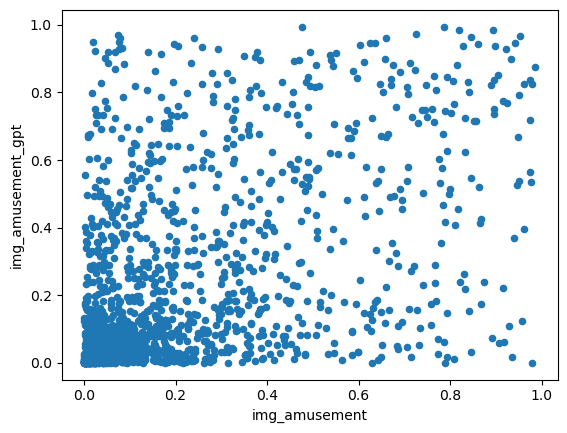

,img_amusement,img_amusement_gpt
img_amusement,1.000000,0.506077
img_amusement_gpt,0.506077,1.000000


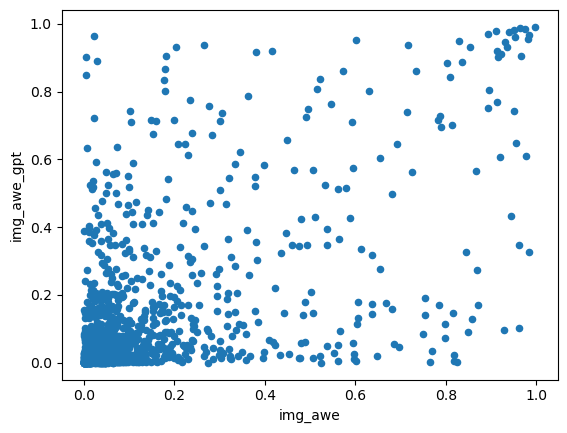

,img_awe,img_awe_gpt
img_awe,1.00000,0.60576
img_awe_gpt,0.60576,1.00000


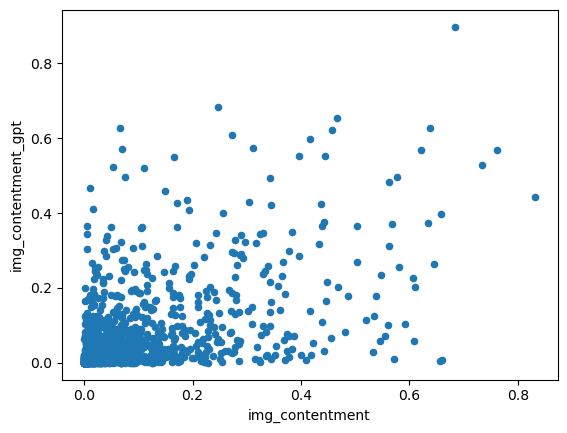

,img_contentment,img_contentment_gpt
img_contentment,1.000000,0.558344
img_contentment_gpt,0.558344,1.000000


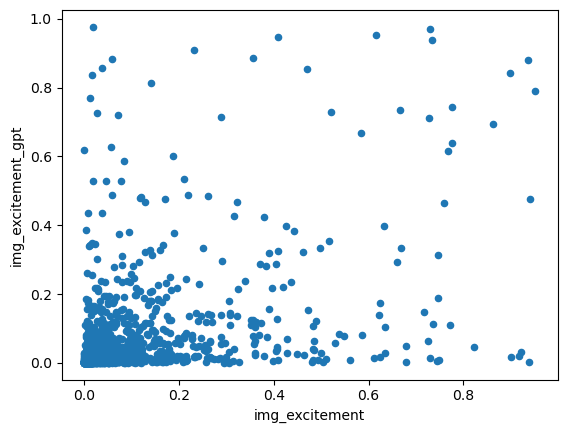

,img_excitement,img_excitement_gpt
img_excitement,1.00000,0.44948
img_excitement_gpt,0.44948,1.00000


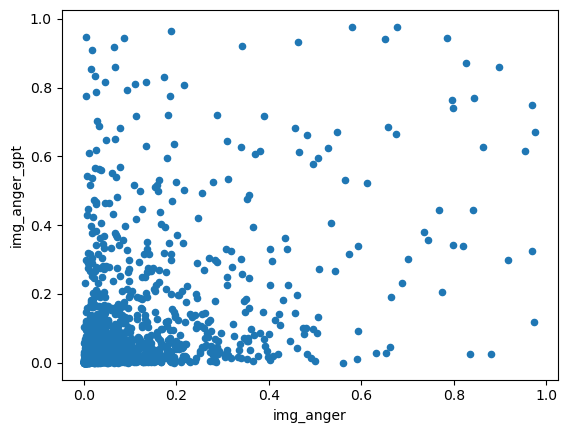

,img_anger,img_anger_gpt
img_anger,1.000000,0.447163
img_anger_gpt,0.447163,1.000000


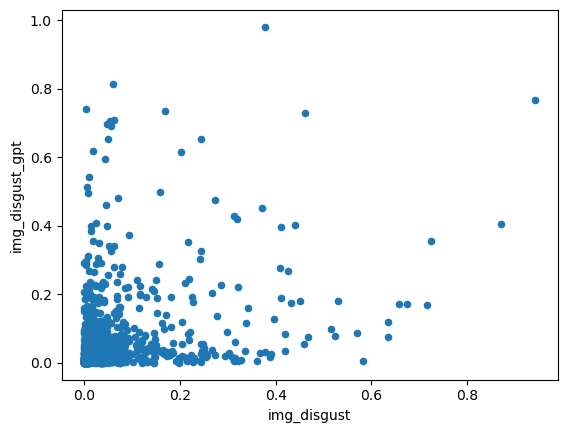

,img_disgust,img_disgust_gpt
img_disgust,1.000000,0.360306
img_disgust_gpt,0.360306,1.000000


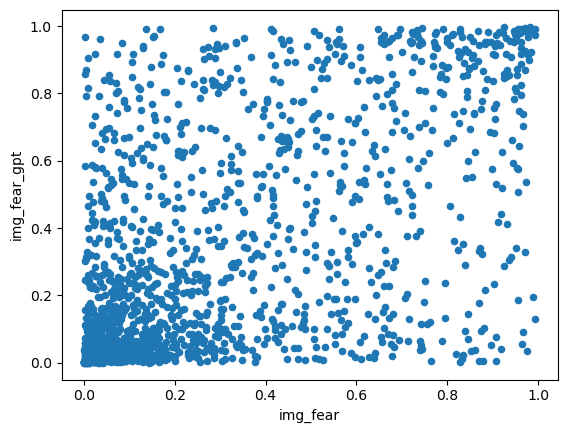

,img_fear,img_fear_gpt
img_fear,1.000000,0.579715
img_fear_gpt,0.579715,1.000000


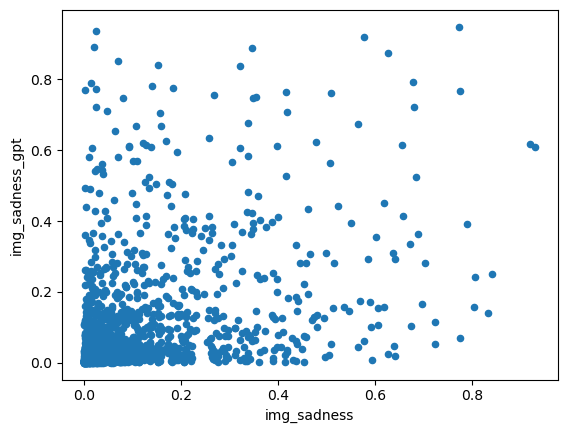

,img_sadness,img_sadness_gpt
img_sadness,1.000000,0.415965
img_sadness_gpt,0.415965,1.000000


In [14]:
for ec in img_emotion_cols:
    merged_df.plot.scatter(ec,ec+"_gpt")
    plt.show()

    display(merged_df[[ec,ec+"_gpt"]].corr())